In [1]:
import os
import re
import rasterio
from rasterio.coords import BoundingBox
from rasterio.windows import Window, from_bounds
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch, Rectangle
import shutil
import random
import pandas as pd
from skimage.transform import resize
from scipy.ndimage import binary_opening, binary_closing
from collections import Counter
from sklearn.model_selection import train_test_split

c:\Users\Agando\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\Agando\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\Users\Agando\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


**Inspect Data**

In [2]:
tile_path = 'data/Final RGB HR Imagery/UH_NAD83_271460_3289689.tif'
with rasterio.open(tile_path) as ds:
    print(ds.bounds)

BoundingBox(left=271460.0, bottom=3289689.0, right=272056.0, top=3290290.0)


In [3]:
# Config
PATCH_SIZE = 256           # pixels
PIXEL_SIZE = 0.05          # meters per pixel (5cm)

# Paths
rgb_folder = 'data/Final RGB HR Imagery'
train_gt_path = 'data/TrainingGT/2018_IEEE_GRSS_DFC_GT_TR.tif'
test_gt_path = 'data/TestingGT/Test_Labels.tif'

# Regex to extract tile origin coords from filename
filename_re = re.compile(r'UH_NAD83_(\d+)_(\d+)\.tif')

def get_bounds(raster_path):
    import rasterio
    with rasterio.open(raster_path) as ds:
        return ds.bounds

def tile_bounds(x, y, tile_width, tile_height, pixel_size=1):
    # Assuming x,y are lower-left corner in world coordinates
    left = x
    bottom = y
    right = x + tile_width * pixel_size
    top = y + tile_height * pixel_size
    return BoundingBox(left=left, bottom=bottom, right=right, top=top)

def bounds_intersect(b1: BoundingBox, b2: BoundingBox):
    return not (b1.right <= b2.left or b1.left >= b2.right or
                b1.top <= b2.bottom or b1.bottom >= b2.top)

# Load GT bounds
train_bounds = get_bounds(train_gt_path)
test_bounds = get_bounds(test_gt_path)

print("Train bounds:", train_bounds)
print("Test bounds:", test_bounds)

train_tiles = []
test_tiles = []

for fname in os.listdir(rgb_folder):
    if not fname.endswith('.tif'):
        continue
    m = filename_re.match(fname)
    if not m:
        continue
    x = int(m.group(1))
    y = int(m.group(2))

    tb = tile_bounds(x, y, PATCH_SIZE, PATCH_SIZE, PIXEL_SIZE)

    if bounds_intersect(tb, train_bounds):
        train_tiles.append(fname)
    elif bounds_intersect(tb, test_bounds):
        test_tiles.append(fname)
    else:
        print(f"Tile {fname} does not overlap train or test bounds!")

print(f"Found {len(train_tiles)} train tiles and {len(test_tiles)} test tiles")


Train bounds: BoundingBox(left=272056.0, bottom=3289689.0, right=274440.0, top=3290290.0)
Test bounds: BoundingBox(left=271460.0, bottom=3289689.0, right=275632.0, top=3290891.0)
Found 4 train tiles and 10 test tiles


Train transform:
| 0.50, 0.00, 272056.00|
| 0.00,-0.50, 3290290.00|
| 0.00, 0.00, 1.00|
Test transform:
| 0.50, 0.00, 271460.00|
| 0.00,-0.50, 3290891.00|
| 0.00, 0.00, 1.00|
Train shape: (1202, 4768)
Test shape: (2404, 8344)
Pixel offset of train GT within test GT: x=1192, y=1202
Number of overlapping labeled pixels (after spatially correct padding): 0


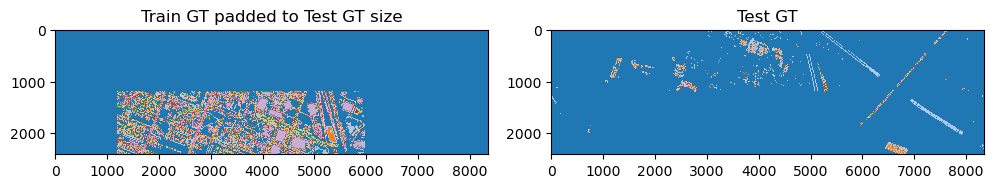

In [4]:
train_gt_path = 'data/TrainingGT/2018_IEEE_GRSS_DFC_GT_TR.tif'
test_gt_path = 'data/TestingGT/Test_Labels.tif'

def read_full(raster_path):
    with rasterio.open(raster_path) as ds:
        data = ds.read(1)
        transform = ds.transform
        shape = data.shape
    return data, transform, shape

def get_bounds(raster_path):
    with rasterio.open(raster_path) as ds:
        return ds.bounds

train_data, train_transform, train_shape = read_full(train_gt_path)
test_data, test_transform, test_shape = read_full(test_gt_path)

train_bounds = get_bounds(train_gt_path)
test_bounds = get_bounds(test_gt_path)

print(f"Train transform:\n{train_transform}")
print(f"Test transform:\n{test_transform}")
print(f"Train shape: {train_shape}")
print(f"Test shape: {test_shape}")

# Calculate pixel offset of train data within test data grid

# Pixel size (assumed same for both)
px_size_x = train_transform.a
px_size_y = -train_transform.e  # negative because Y axis inverted

# Compute offsets in pixels (rounded to int)
offset_x = int(round((train_bounds.left - test_bounds.left) / px_size_x))
offset_y = int(round((test_bounds.top - train_bounds.top) / px_size_y))  # because Y axis inverted

print(f"Pixel offset of train GT within test GT: x={offset_x}, y={offset_y}")

# Create padded array for train to match test size
padded_train = np.zeros(test_shape, dtype=train_data.dtype)

# Place train data into padded array
padded_train[offset_y:offset_y+train_shape[0], offset_x:offset_x+train_shape[1]] = train_data

# Now compare and plot

overlap_mask = (padded_train > 0) & (test_data > 0)
num_overlap_pixels = np.sum(overlap_mask)
print(f"Number of overlapping labeled pixels (after spatially correct padding): {num_overlap_pixels}")

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Train GT padded to Test GT size")
plt.imshow(padded_train, cmap='tab20')

plt.subplot(1,3,2)
plt.title("Test GT")
plt.imshow(test_data, cmap='tab20')

plt.tight_layout()
plt.show()


In [5]:
rgb_folder = 'data/Final RGB HR Imagery'

# Pick the first .tif tile to inspect
for fname in os.listdir(rgb_folder):
    if fname.endswith('.tif'):
        tile_path = os.path.join(rgb_folder, fname)
        with rasterio.open(tile_path) as src:
            print(f"Tile: {fname}")
            print(f"Shape (height x width): {src.height} x {src.width}")
            print(f"Number of channels: {src.count}")
        break

Tile: UH_NAD83_271460_3289689.tif
Shape (height x width): 12020 x 11920
Number of channels: 3


**Extract Patches**

In [6]:
# labels are 10x lower resolution!!!
def print_pixel_sizes(rgb_path, train_gt_path, test_gt_path):
    with rasterio.open(rgb_path) as rgb_ds, \
         rasterio.open(train_gt_path) as train_gt_ds, \
         rasterio.open(test_gt_path) as test_gt_ds:

        rgb_pix_x = rgb_ds.transform.a
        rgb_pix_y = rgb_ds.transform.e
        train_pix_x = train_gt_ds.transform.a
        train_pix_y = train_gt_ds.transform.e
        test_pix_x = test_gt_ds.transform.a
        test_pix_y = test_gt_ds.transform.e

        print(f"RGB pixel size: ({abs(rgb_pix_x):.4f}, {abs(rgb_pix_y):.4f})")
        print(f"Train GT pixel size: ({abs(train_pix_x):.4f}, {abs(train_pix_y):.4f})")
        print(f"Test GT pixel size: ({abs(test_pix_x):.4f}, {abs(test_pix_y):.4f})")

# Example usage:
print_pixel_sizes(
    'data/Final RGB HR Imagery/UH_NAD83_271460_3289689.tif',
    'data/TrainingGT/2018_IEEE_GRSS_DFC_GT_TR.tif',
    'data/TestingGT/Test_Labels.tif'
)

RGB pixel size: (0.0500, 0.0500)
Train GT pixel size: (0.5000, 0.5000)
Test GT pixel size: (0.5000, 0.5000)


In [5]:
PATCH_SIZE = 256  # size in RGB pixels
STRIDE = 256      # stride in RGB pixels

def extract_patches(split='train'):
    import os
    import numpy as np
    import rasterio

    assert split in ['train', 'test'], "Split must be 'train' or 'test'"

    rgb_folder = 'data/Final RGB HR Imagery'
    gt_path = {
        'train': 'data/TrainingGT/2018_IEEE_GRSS_DFC_GT_TR.tif',
        'test':  'data/TestingGT/Test_Labels.tif'
    }[split]
    output_folder = f'data/patches/{split}'
    os.makedirs(output_folder, exist_ok=True)

    with rasterio.open(gt_path) as gt_ds, rasterio.open(os.path.join(rgb_folder, os.listdir(rgb_folder)[0])) as sample_rgb_ds:
        gt_data = gt_ds.read(1)
        gt_transform = gt_ds.transform
        gt_pix_x = abs(gt_transform.a)
        gt_pix_y = abs(gt_transform.e)

        rgb_pix_x = abs(sample_rgb_ds.transform.a)
        rgb_pix_y = abs(sample_rgb_ds.transform.e)

        print(f"GT pixel size: ({gt_pix_x}, {gt_pix_y})")
        print(f"RGB pixel size: ({rgb_pix_x}, {rgb_pix_y})")

        # Compute scale factor between GT and RGB pixel sizes (assuming same scale for x/y)
        scale_x = gt_pix_x / rgb_pix_x
        scale_y = gt_pix_y / rgb_pix_y
        assert abs(scale_x - scale_y) < 1e-6, "Non-uniform pixel scaling not supported"
        scale = scale_x

        print(f"Scale factor between GT and RGB pixels: {scale}")

        for fname in os.listdir(rgb_folder):
            if not fname.endswith('.tif'):
                continue

            parts = fname.rstrip('.tif').split('_')
            min_x, min_y = float(parts[-2]), float(parts[-1])

            with rasterio.open(os.path.join(rgb_folder, fname)) as rgb_ds:
                rgb_tile = rgb_ds.read()  # (bands, H, W)
                rgb_height, rgb_width = rgb_ds.height, rgb_ds.width

                # Convert bottom-left tile origin to top-left coordinates
                top_left_x = min_x
                top_left_y = min_y + rgb_pix_y * rgb_height  # rgb_pix_y is positive here; use abs if negative

                # Map top-left coordinate into GT pixel coordinates
                gt_col_f, gt_row_f = ~gt_transform * (top_left_x, top_left_y)
                gt_row, gt_col = int(np.floor(gt_row_f)), int(np.floor(gt_col_f))

                # Calculate GT tile size to match RGB tile spatial extent
                rgb_tile_width_m = rgb_pix_x * rgb_width
                rgb_tile_height_m = rgb_pix_y * rgb_height

                gt_tile_width_px = int(round(rgb_tile_width_m / gt_pix_x))
                gt_tile_height_px = int(round(rgb_tile_height_m / gt_pix_y))

                # Check GT bounds for this tile
                if (gt_row < 0 or gt_col < 0 or
                    gt_row + gt_tile_height_px > gt_data.shape[0] or
                    gt_col + gt_tile_width_px > gt_data.shape[1]):
                    print(f"Skipping {fname} because it is out of GT bounds.")
                    continue

                # Extract GT tile and resize it to match RGB tile resolution
                gt_tile = gt_data[gt_row:gt_row + gt_tile_height_px, gt_col:gt_col + gt_tile_width_px]
                gt_tile_resized = resize(
                    gt_tile,
                    (rgb_height, rgb_width),
                    order=0,              # nearest neighbor
                    preserve_range=True,
                    anti_aliasing=False
                ).astype(gt_tile.dtype)

                # Extract patches
                for y in range(0, rgb_height - PATCH_SIZE + 1, STRIDE):
                    for x in range(0, rgb_width - PATCH_SIZE + 1, STRIDE):
                        rgb_patch = rgb_tile[:, y:y + PATCH_SIZE, x:x + PATCH_SIZE]
                        gt_patch = gt_tile_resized[y:y + PATCH_SIZE, x:x + PATCH_SIZE]

                        if gt_patch.shape != (PATCH_SIZE, PATCH_SIZE):
                            continue
                        if np.all(gt_patch == 0):
                            continue

                        # Optional: Smooth labels per class (except background)
                        #smoothed_gt = np.zeros_like(gt_patch)
                        #for cls in np.unique(gt_patch):
                        #    if cls == 0:
                        #        continue
                        #    mask = (gt_patch == cls)
                        #    mask = binary_opening(mask, structure=np.ones((3,3)))
                        #    mask = binary_closing(mask, structure=np.ones((3,3)))
                        #    smoothed_gt[mask] = cls

                        # Save patches
                        patch_name = f"{fname[:-4]}_x{x}_y{y}"
                        np.save(f"{output_folder}/{patch_name}_img.npy", rgb_patch)
                        np.save(f"{output_folder}/{patch_name}_label.npy", gt_patch)

    print(f"Done. Patches saved to {output_folder}/")


In [ ]:
#extract_patches('train')  # for training set
#extract_patches('test')   # for test set

GT pixel size: (0.5, 0.5)
RGB pixel size: (0.05, 0.05)
Scale factor between GT and RGB pixels: 10.0
Skipping UH_NAD83_271460_3289689.tif because it is out of GT bounds.
Skipping UH_NAD83_271460_3290290.tif because it is out of GT bounds.
Skipping UH_NAD83_272056_3290290.tif because it is out of GT bounds.
Skipping UH_NAD83_272652_3290290.tif because it is out of GT bounds.
Skipping UH_NAD83_273248_3290290.tif because it is out of GT bounds.
Skipping UH_NAD83_273844_3290290.tif because it is out of GT bounds.
Skipping UH_NAD83_274440_3289689.tif because it is out of GT bounds.
Skipping UH_NAD83_274440_3290290.tif because it is out of GT bounds.
Skipping UH_NAD83_275036_3289689.tif because it is out of GT bounds.
Skipping UH_NAD83_275036_3290290.tif because it is out of GT bounds.
Done. Patches saved to data/patches/train/
GT pixel size: (0.5, 0.5)
RGB pixel size: (0.05, 0.05)
Scale factor between GT and RGB pixels: 10.0
Done. Patches saved to data/patches/test/


In [17]:
def compute_label_stats(label_dir):
    label_files = [f for f in os.listdir(label_dir) if f.endswith('_label.npy')]

    total_pixels = 0
    labeled_pixels = 0

    for fname in label_files:
        label_path = os.path.join(label_dir, fname)
        label = np.load(label_path)

        total_pixels += label.size
        labeled_pixels += np.count_nonzero(label)

    ratio = labeled_pixels / total_pixels if total_pixels else 0
    return len(label_files), total_pixels, labeled_pixels, ratio

# Paths to your patch directories
train_label_dir = 'data/patches/train'
test_label_dir = 'data/patches/test'

# Train stats
train_count, train_total, train_labeled, train_ratio = compute_label_stats(train_label_dir)
print(f"\nTrain:")
print(f"Patches: {train_count}")
print(f"Total pixels: {train_total}")
print(f"Labeled pixels: {train_labeled}")
print(f"Labeled pixel ratio: {train_ratio:.4f}")

# Test stats
test_count, test_total, test_labeled, test_ratio = compute_label_stats(test_label_dir)
print(f"\nTest:")
print(f"Patches: {test_count}")
print(f"Total pixels: {test_total}")
print(f"Labeled pixels: {test_labeled}")
print(f"Labeled pixel ratio: {test_ratio:.4f}")


Train:
Patches: 4063
Total pixels: 266272768
Labeled pixels: 163230496
Labeled pixel ratio: 0.6130

Test:
Patches: 17409
Total pixels: 1140916224
Labeled pixels: 33149920
Labeled pixel ratio: 0.0291


**Check Patch Alignment**

In [3]:
class_info = {
    0:  ('Unclassified',            (0,   0,   0  )),    # Black / No data
    1:  ('Healthy grass',           (0,  255,   0  )),    # Bright green
    2:  ('Stressed grass',          (128, 128,  0  )),    # Olive / dull green
    3:  ('Artificial turf',         (0,  200,  0  )),    # Medium green
    4:  ('Evergreen trees',         (0,  100,   0  )),    # Dark green
    5:  ('Deciduous trees',         (34, 139,  34  )),    # Forest green
    6:  ('Bare earth',              (210, 180, 140 )),    # Tan / sandy brown
    7:  ('Water',                   (0,    0, 255  )),    # Blue
    8:  ('Residential buildings',  (255,  0,    0  )),    # Red
    9:  ('Non-residential buildings',(139, 0,    0  )),   # Dark red
    10: ('Roads',                   (128, 128, 128 )),    # Gray
    11: ('Sidewalks',               (192, 192, 192 )),    # Light gray
    12: ('Crosswalks',              (255, 255, 255 )),    # White
    13: ('Major thoroughfares',     (255, 165,   0  )),    # Orange
    14: ('Highways',                (255, 140,   0  )),    # Dark orange
    15: ('Railways',                (139, 69,   19  )),    # Saddle brown
    16: ('Paved parking lots',      (169, 169, 169 )),    # Dark gray
    17: ('Unpaved parking lots',    (205, 133,  63  )),    # Peru brown
    18: ('Cars',                    (255, 20,    147 )),   # Deep pink
    19: ('Trains',                  (75,  0,   130  )),    # Indigo / purple
    20: ('Stadium seats',           (255, 215,   0  )),    # Gold / yellow
}

In [4]:
def extract_matching_gt_patch(rgb_tile_path, gt_path):
    with rasterio.open(rgb_tile_path) as rgb_ds:
        rgb_img = rgb_ds.read([1, 2, 3])  # assuming RGB bands 1,2,3
        rgb_transform = rgb_ds.transform
        rgb_width = rgb_ds.width
        rgb_height = rgb_ds.height
        rgb_bounds = rgb_ds.bounds

    with rasterio.open(gt_path) as gt_ds:
        gt_data = gt_ds.read(1)
        gt_transform = gt_ds.transform

        top_left_x = rgb_bounds.left
        top_left_y = rgb_bounds.top

        gt_col_f, gt_row_f = ~gt_transform * (top_left_x, top_left_y)
        gt_row, gt_col = int(np.floor(gt_row_f)), int(np.floor(gt_col_f))

        gt_pix_size_x = abs(gt_transform.a)
        gt_pix_size_y = abs(gt_transform.e)

        rgb_pix_size_x = abs(rgb_transform.a)
        rgb_pix_size_y = abs(rgb_transform.e)

        gt_tile_width_px = int(round((rgb_width * rgb_pix_size_x) / gt_pix_size_x))
        gt_tile_height_px = int(round((rgb_height * rgb_pix_size_y) / gt_pix_size_y))

        gt_patch = gt_data[gt_row:gt_row + gt_tile_height_px, gt_col:gt_col + gt_tile_width_px]

    return rgb_img, gt_patch

def plot_rgb_and_gt(rgb_img, gt_patch, class_info):
    fig, axs = plt.subplots(1, 2, figsize=(15, 10))

    # Normalize and transpose RGB image for display (H, W, C)
    rgb_img_disp = np.transpose(rgb_img, (1, 2, 0))
    rgb_img_disp = rgb_img_disp / np.max(rgb_img_disp + 1e-6)  # safe division

    axs[0].imshow(rgb_img_disp)
    axs[0].set_title("RGB Tile", fontweight='bold')
    axs[0].axis('off')

    # Create an RGB image for GT patch based on class colors
    h, w = gt_patch.shape
    gt_rgb = np.zeros((h, w, 3), dtype=np.float32)

    for class_id, (class_name, color) in class_info.items():
        color_norm = np.array(color) / 255.0
        gt_rgb[gt_patch == class_id] = color_norm

    axs[1].imshow(gt_rgb)
    axs[1].set_title("Reference", fontweight='bold')
    axs[1].axis('off')

    # Create legend
    legend_elements = [
        Patch(facecolor=np.array(color)/255.0, edgecolor='black', label=class_name)
        for class_id, (class_name, color) in class_info.items()
    ]
    legend = axs[1].legend(
        handles=legend_elements,
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        title="Classes",
        fontsize=12
    )
    legend.get_title().set_fontsize(12)    # title font size
    legend.get_title().set_fontweight('bold')  # title bold

    plt.tight_layout()
    plt.show()
    

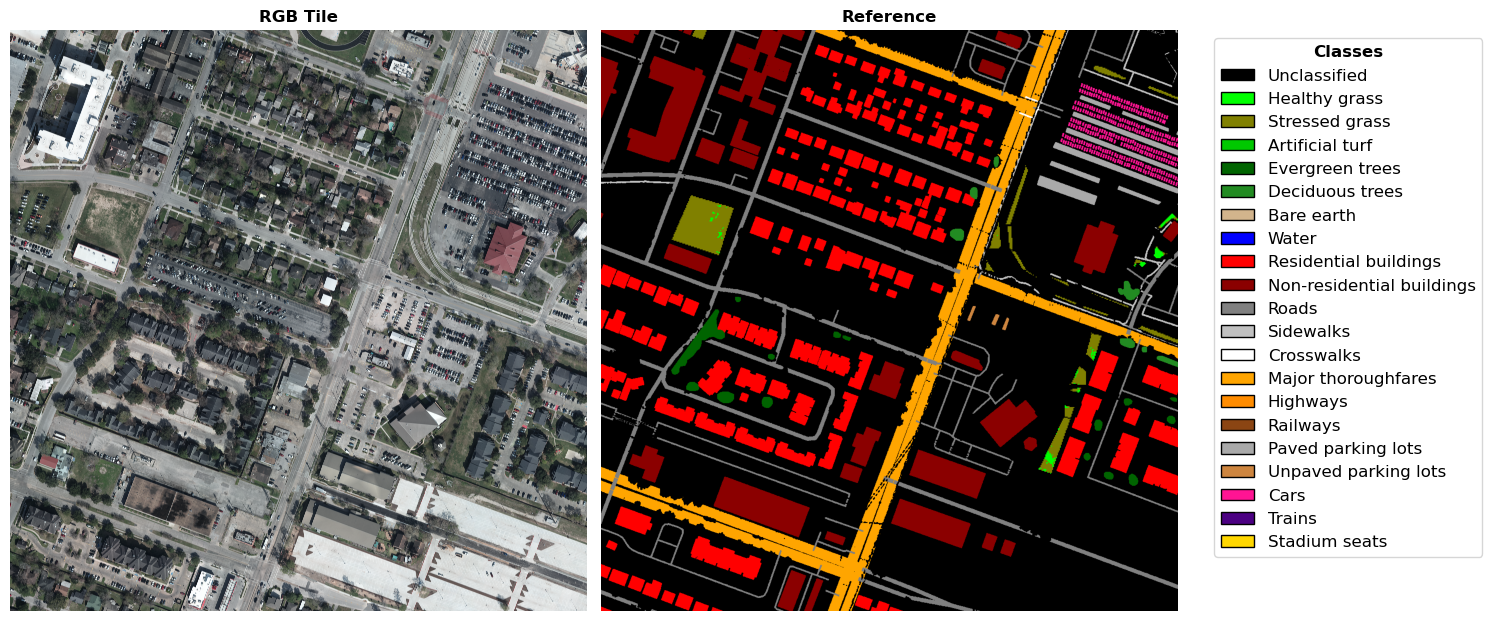

In [5]:
rgb_tile_file = 'data/Final RGB HR Imagery/UH_NAD83_272056_3289689.tif'
gt_file = 'data/TrainingGT/2018_IEEE_GRSS_DFC_GT_TR.tif'

rgb_img, gt_patch = extract_matching_gt_patch(rgb_tile_file, gt_file)
plot_rgb_and_gt(rgb_img, gt_patch, class_info)

[ 0 16 18]


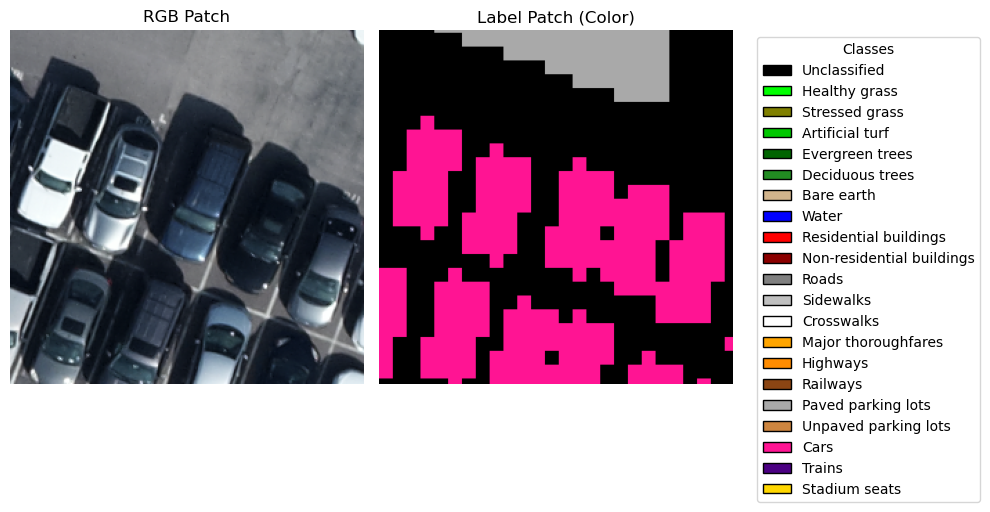

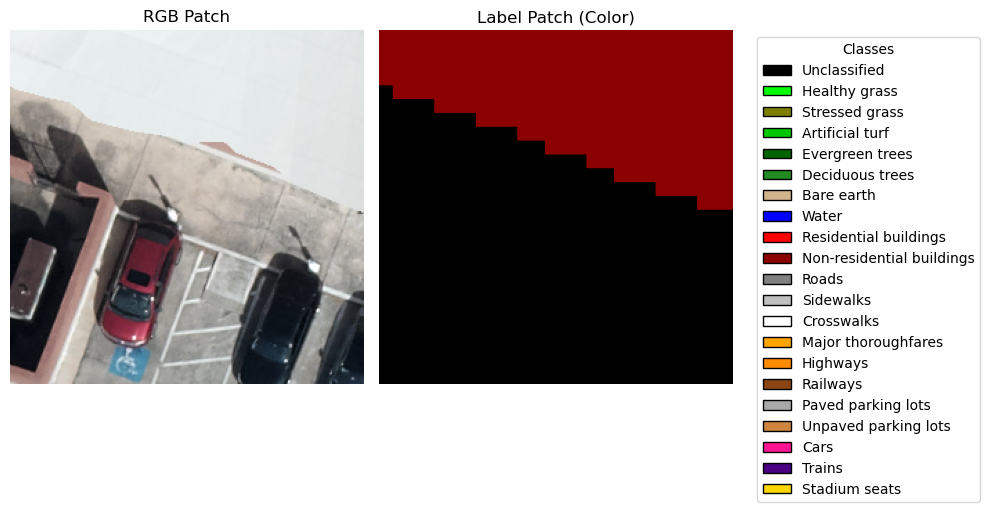

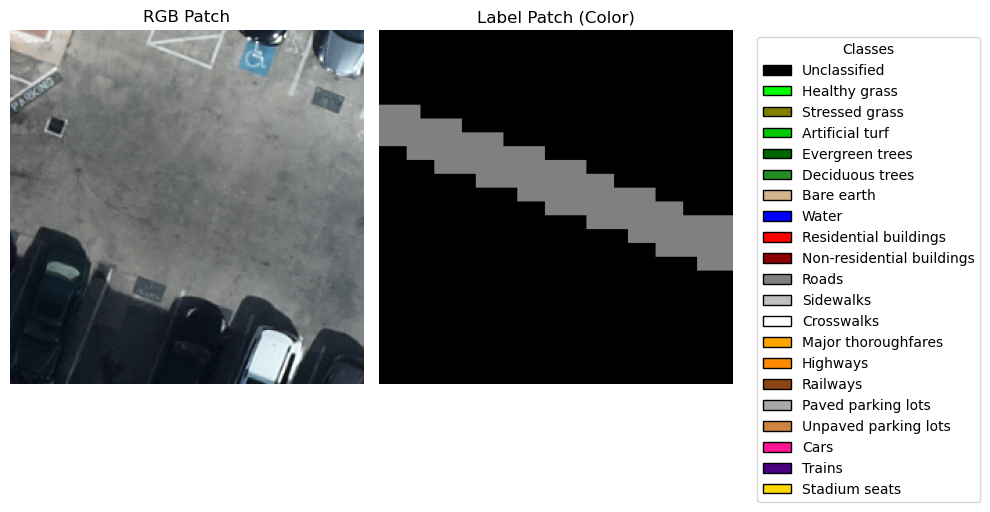

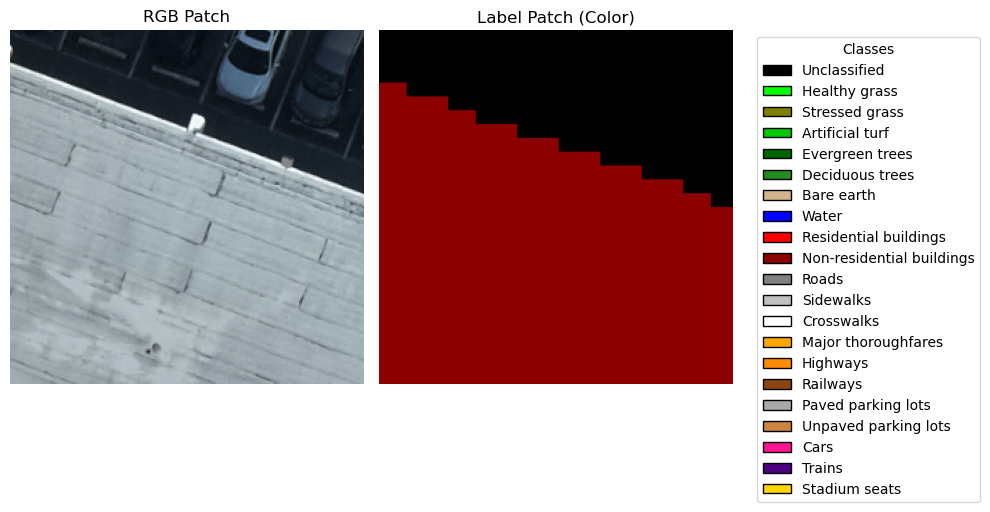

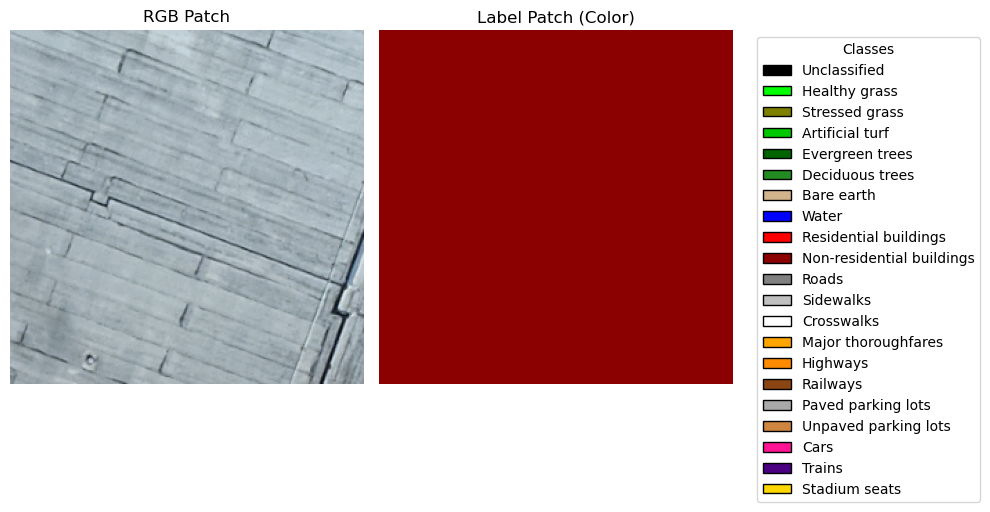

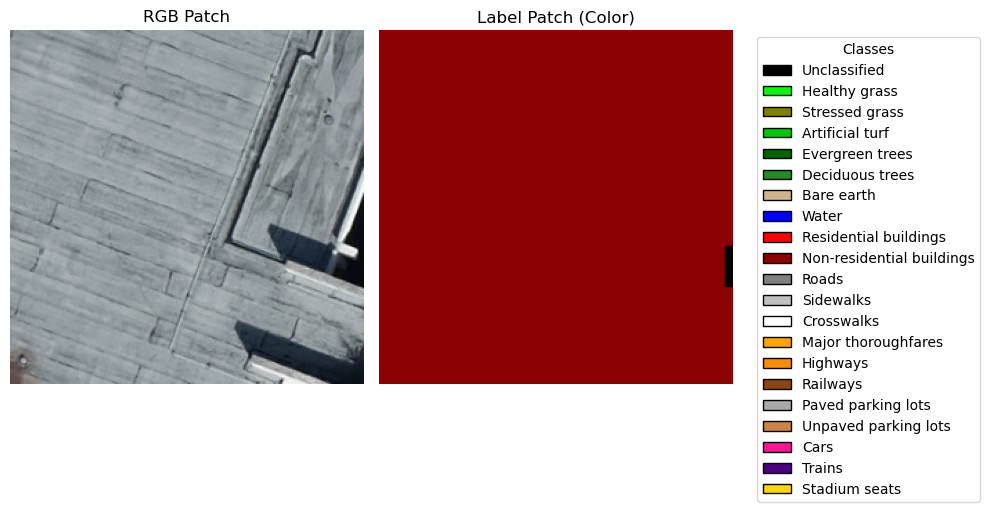

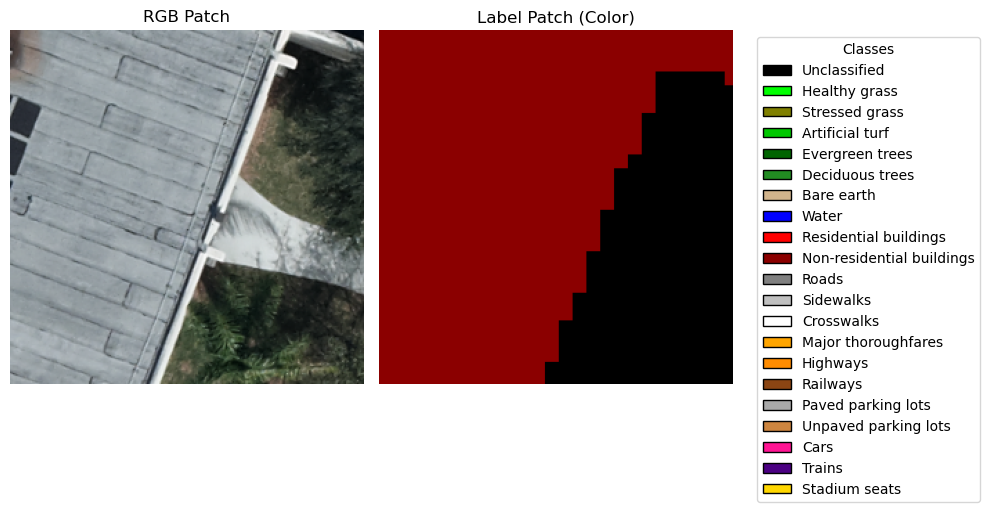

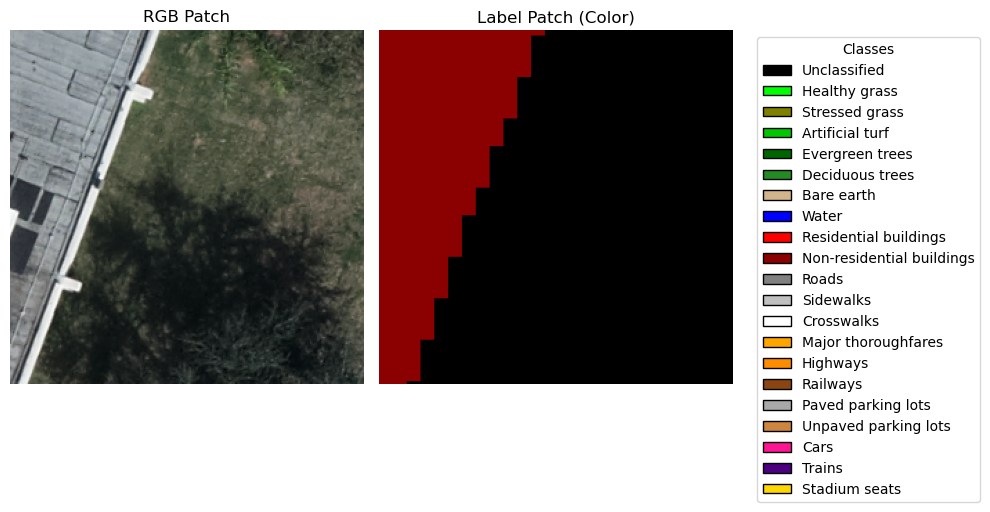

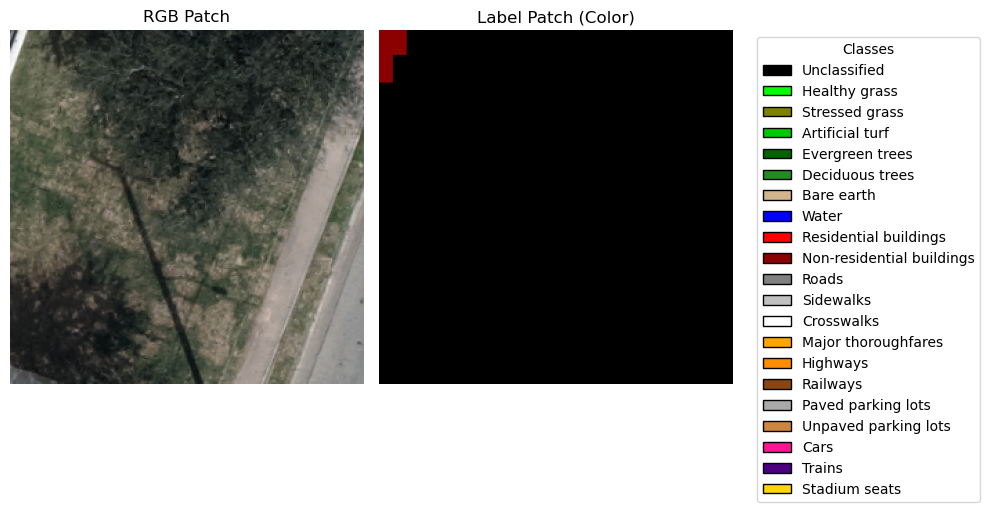

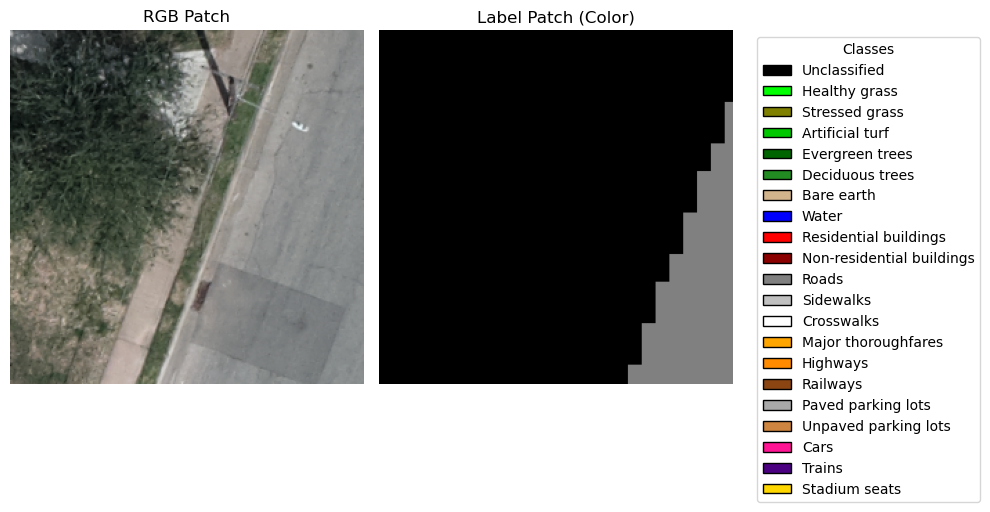

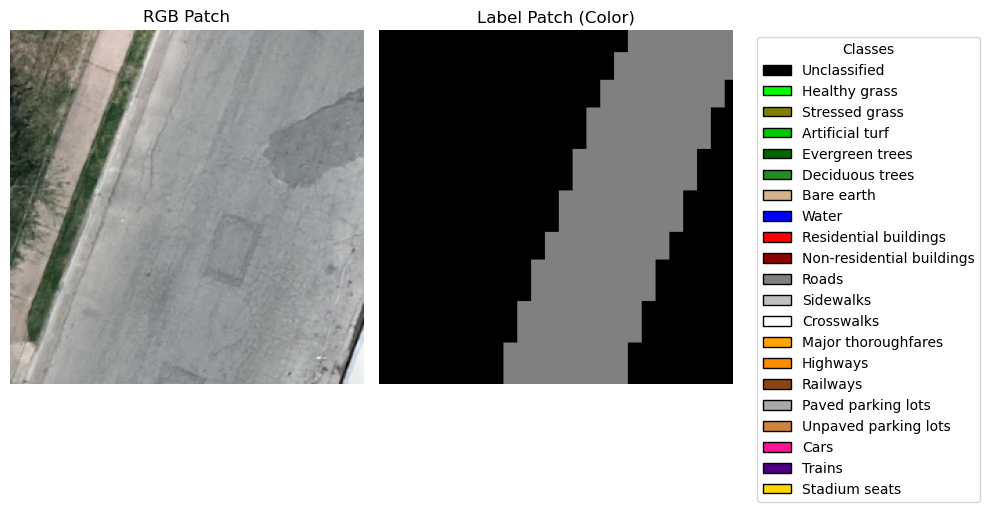

In [13]:
def visualize_patch(rgb_patch, label_patch):
    # Normalize RGB
    image = rgb_patch.astype(np.float32)
    image = np.clip((image - image.min()) / (image.max() - image.min() + 1e-6), 0, 1)
    image = np.transpose(image, (1, 2, 0))

    # Create ID → color LUT
    id_to_color = np.zeros((max(class_info.keys()) + 1, 3), dtype=np.uint8)
    for class_id, (_, color) in class_info.items():
        id_to_color[class_id] = color

    # Map label_patch to RGB
    label_rgb = id_to_color[label_patch]

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(image)
    ax[0].set_title("RGB Patch")
    ax[0].axis("off")

    ax[1].imshow(label_rgb)
    ax[1].set_title("Label Patch (Color)")
    ax[1].axis("off")

    # Add legend
    legend_elements = [
        Patch(facecolor=np.array(color)/255, edgecolor='black', label=name)
        for name, color in class_info.values()
    ]
    plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', title="Classes")

    plt.tight_layout()
    plt.show()

img = np.load(f'data/patches/train/UH_NAD83_272056_3289689_x11520_y2048_img.npy')
lbl = np.load(f'data/patches/train/UH_NAD83_272056_3289689_x11520_y2048_label.npy')
print(np.unique(lbl))
visualize_patch(img, lbl)

for i in range(10):
    #if os.path.exists(f'data/patches/train/UH_NAD83_272056_3289689_x{i*256}_y0_img.npy'):
    if os.path.exists(f'data/patches/train/UH_NAD83_272056_3289689_x0_y{i*256}_img.npy'):
        #img = np.load(f'data/patches/train/UH_NAD83_272056_3289689_x0_y{i*256}_img.npy')
        #lbl = np.load(f'data/patches/train/UH_NAD83_272056_3289689_x0_y{i*256}_label.npy')
        img = np.load(f'data/patches/train/UH_NAD83_272056_3289689_x0_y{i*256}_img.npy')
        lbl = np.load(f'data/patches/train/UH_NAD83_272056_3289689_x0_y{i*256}_label.npy')
        visualize_patch(img, lbl)
#np.count_nonzero(lbl) #looks like there is still label noise in test labels for train patches


**Remove very sparsely labeled Patches**

In [14]:
# mby dont
""" 
label_dir = 'data/patches/test'  # or train
deleted = 0

for fname in os.listdir(label_dir):
    if fname.endswith('_label.npy'):
        label_path = os.path.join(label_dir, fname)
        label = np.load(label_path)
        #print("Unique labels in patch:", np.unique(label))
        #if np.all(label == 0):
        label_fraction = np.count_nonzero(label) / label.size
        if label_fraction < 0.01:  # less than 1% labeled
            # Delete both label and corresponding image
            os.remove(label_path)
            img_path = label_path.replace('_label.npy', '_img.npy')
            if os.path.exists(img_path):
                os.remove(img_path)
            deleted += 1

print(f"Deleted {deleted} sparsely labeled patches.")
"""

' \nlabel_dir = \'data/patches/test\'  # or train\ndeleted = 0\n\nfor fname in os.listdir(label_dir):\n    if fname.endswith(\'_label.npy\'):\n        label_path = os.path.join(label_dir, fname)\n        label = np.load(label_path)\n        #print("Unique labels in patch:", np.unique(label))\n        #if np.all(label == 0):\n        label_fraction = np.count_nonzero(label) / label.size\n        if label_fraction < 0.01:  # less than 1% labeled\n            # Delete both label and corresponding image\n            os.remove(label_path)\n            img_path = label_path.replace(\'_label.npy\', \'_img.npy\')\n            if os.path.exists(img_path):\n                os.remove(img_path)\n            deleted += 1\n\nprint(f"Deleted {deleted} sparsely labeled patches.")\n'

In [15]:
# Paths to your patch directories
train_label_dir = 'data/patches/train'
test_label_dir = 'data/patches/test'

# Train stats
train_count, train_total, train_labeled, train_ratio = compute_label_stats(train_label_dir)
print(f"\nTrain:")
print(f"Patches: {train_count}")
print(f"Total pixels: {train_total}")
print(f"Labeled pixels: {train_labeled}")
print(f"Labeled pixel ratio: {train_ratio:.4f}")

# Test stats
test_count, test_total, test_labeled, test_ratio = compute_label_stats(test_label_dir)
print(f"\nTest:")
print(f"Patches: {test_count}")
print(f"Total pixels: {test_total}")
print(f"Labeled pixels: {test_labeled}")
print(f"Labeled pixel ratio: {test_ratio:.4f}")


Train:
Patches: 6951
Total pixels: 455540736
Labeled pixels: 196639780
Labeled pixel ratio: 0.4317

Test:
Patches: 17409
Total pixels: 1140916224
Labeled pixels: 33149920
Labeled pixel ratio: 0.0291


**Inspect Original Class Distribution**

Class ID                Class Name  Train Pixels Train %  Test Pixels  Test %
       1             Healthy grass         39196   1.94%        20000   5.85%
       2            Stressed grass        130008   6.44%        20000   5.85%
       3           Artificial turf          2736   0.14%        20000   5.85%
       4           Evergreen trees         54322   2.69%        20000   5.85%
       5           Deciduous trees         20172   1.00%        20000   5.85%
       6                Bare earth         18064   0.89%        20000   5.85%
       7                     Water          1064   0.05%         1628   0.48%
       8     Residential buildings        158995   7.88%        20000   5.85%
       9 Non-residential buildings        894769  44.32%        20000   5.85%
      10                     Roads        183283   9.08%        20000   5.85%
      11                 Sidewalks        136035   6.74%        20000   5.85%
      12                Crosswalks          6059   0.30%        

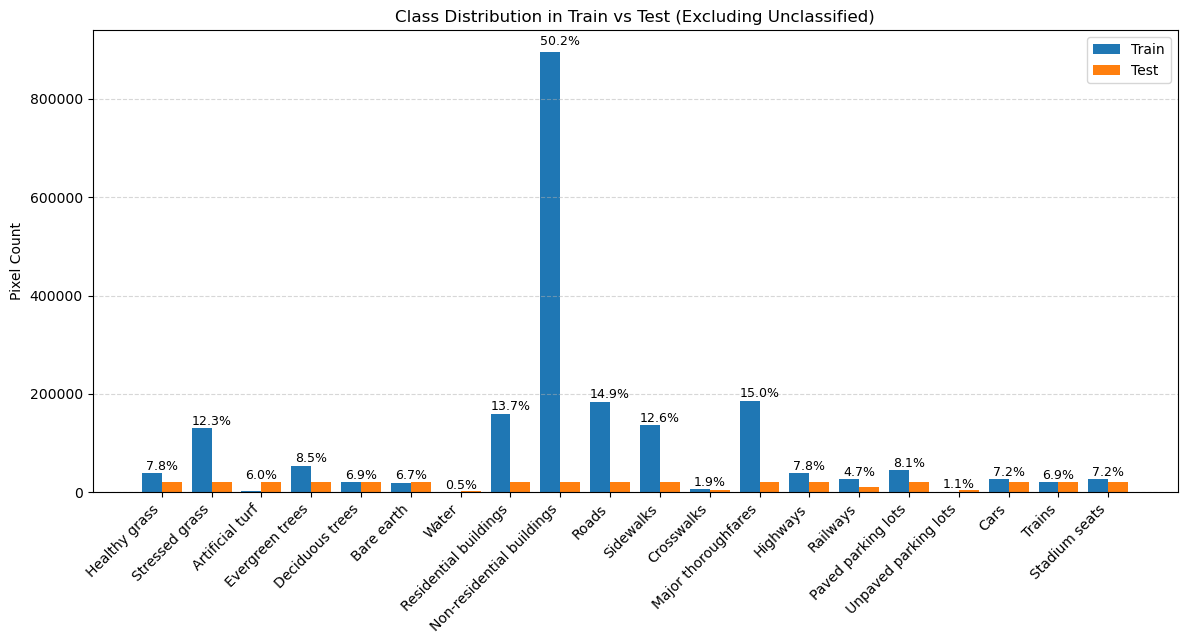

In [16]:
### THIS IS FOR WHOLE GT RASTER ###

# Load GT rasters
train_gt_path = 'data/TrainingGT/2018_IEEE_GRSS_DFC_GT_TR.tif'
test_gt_path = 'data/TestingGT/Test_Labels.tif'

with rasterio.open(train_gt_path) as src:
    train_gt = src.read(1)

with rasterio.open(test_gt_path) as src:
    test_gt = src.read(1)

# Classes 1 to 20
class_ids = list(range(1, 21))
class_names = [class_info[i][0] for i in class_ids]
train_counts = [np.sum(train_gt == i) for i in class_ids]
test_counts = [np.sum(test_gt == i) for i in class_ids]

# Totals for percentages
total_train_labeled = np.sum(train_counts)
total_test_labeled = np.sum(test_counts)

# Percentages
train_pct = [cnt / total_train_labeled * 100 if total_train_labeled else 0 for cnt in train_counts]
test_pct = [cnt / total_test_labeled * 100 if total_test_labeled else 0 for cnt in test_counts]

# Prepare DataFrame with sum row
df = pd.DataFrame({
    'Class ID': class_ids,
    'Class Name': class_names,
    'Train Pixels': train_counts,
    'Train %': [f"{p:.2f}%" for p in train_pct],
    'Test Pixels': test_counts,
    'Test %': [f"{p:.2f}%" for p in test_pct]
})

# Add total row
total_row = pd.DataFrame({
    'Class ID': ['-'],
    'Class Name': ['Total'],
    'Train Pixels': [total_train_labeled],
    'Train %': ['100.00%'],
    'Test Pixels': [total_test_labeled],
    'Test %': ['100.00%']
})

df = pd.concat([df, total_row], ignore_index=True)

print(df.to_string(index=False))

# Plot
x = np.arange(len(class_ids))
width = 0.4

plt.figure(figsize=(14, 6))
bars_train = plt.bar(x - width/2, train_counts, width=width, label='Train')
bars_test = plt.bar(x + width/2, test_counts, width=width, label='Test')
plt.xticks(x, class_names, rotation=45, ha='right')
plt.ylabel('Pixel Count')
plt.title('Class Distribution in Train vs Test (Excluding Unclassified)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Annotate sum of percentages on top of bars (train + test)
for i in range(len(class_ids)):
    pct_sum = train_pct[i] + test_pct[i]
    height = max(bars_train[i].get_height(), bars_test[i].get_height())
    plt.text(x[i], height * 1.01, f'{pct_sum:.1f}%', ha='center', va='bottom', fontsize=9, color='black')


**Create Validation Set**

In [ ]:
def compute_patch_class_counts(label_dir, max_class=20):
    label_files = [f for f in os.listdir(label_dir) if f.endswith('_label.npy')]
    class_counts = np.zeros(max_class+1, dtype=np.int64)
    for fname in label_files:
        label = np.load(os.path.join(label_dir, fname))
        for c in range(max_class+1):
            class_counts[c] += np.sum(label == c)
    return class_counts

def select_val_stratified_by_majority(train_dir, val_dir, target_val_pixels, train_counts, max_class=20, min_fraction=0.5):
    os.makedirs(val_dir, exist_ok=True)
    patch_files = [f for f in os.listdir(train_dir) if f.endswith('_label.npy')]

    # Compute patch infos
    patch_infos = []
    for fname in patch_files:
        label = np.load(os.path.join(train_dir, fname))
        counts = np.array([(label == c).sum() for c in range(max_class + 1)])
        labeled = counts[1:].sum()
        if labeled == 0:
            continue
        # majority class excluding class 0
        maj_class = counts[1:].argmax() + 1
        patch_infos.append({'fname': fname, 'counts': counts, 'labeled': labeled, 'maj_class': maj_class})

    # Train distribution proportions excluding class 0
    train_counts_excl0 = train_counts[1:]
    train_total = train_counts_excl0.sum()
    train_props = train_counts_excl0 / train_total

    # Calculate target pixels per class for val (min_fraction ensures no class is less than that fraction of train proportion)
    target_per_class = np.maximum(train_props * target_val_pixels, min_fraction * train_props * target_val_pixels)

    # Group patches by majority class
    patches_by_class = {c: [] for c in range(1, max_class+1)}
    for p in patch_infos:
        patches_by_class[p['maj_class']].append(p)

    # Sort each class group by patch density (labeled pixels ascending) --> stable learning & less patches in training
    for c in patches_by_class:
        patches_by_class[c].sort(key=lambda x: x['labeled'])

    val_selected = set()
    val_class_accum = np.zeros(max_class + 1, dtype=np.int64)

    # Select patches per class to reach target pixels
    for c in range(1, max_class+1):
        target_pixels = target_per_class[c-1]
        class_patches = patches_by_class[c]
        class_pixel_accum = 0
        for p in class_patches:
            if class_pixel_accum >= target_pixels:
                break
            if p['fname'] in val_selected:
                continue
            val_selected.add(p['fname'])
            val_class_accum += p['counts']
            class_pixel_accum += p['labeled']

    # If still below target_val_pixels overall, add most dense remaining patches regardless of class
    total_val_pixels = val_class_accum[1:].sum()
    remaining_patches = [p for p in patch_infos if p['fname'] not in val_selected]
    remaining_patches.sort(key=lambda x: x['labeled'], reverse=True)

    for p in remaining_patches:
        if total_val_pixels >= target_val_pixels:
            break
        val_selected.add(p['fname'])
        val_class_accum += p['counts']
        total_val_pixels = val_class_accum[1:].sum()

    # Move selected patches to val_dir
    #for fname in val_selected:
    #    base = fname.replace('_label.npy', '')
    #    for suffix in ['_label.npy', '_img.npy']:
    #        src = os.path.join(train_dir, base + suffix)
    #        dst = os.path.join(val_dir, base + suffix)
    #        if os.path.exists(src):
    #            shutil.move(src, dst)

    print(f"Selected {len(val_selected)} patches for validation.")
    print(f"Total labeled pixels in val: {val_class_accum[1:].sum():,}")
    for i in range(1, max_class+1):
        print(f"Class {i:2d}: {val_class_accum[i]:7d}")


In [14]:
train_label_dir = 'data/patches/train'
val_label_dir = 'data/patches/val'
test_label_dir = 'data/patches/test'

train_counts = compute_patch_class_counts(train_label_dir)
test_counts = compute_patch_class_counts(test_label_dir)

target_val_pixels = test_counts[1:].sum()  # matching test labeled pixels

select_val_stratified_by_majority(
    train_dir=train_label_dir,
    val_dir=val_label_dir,
    target_val_pixels=target_val_pixels,
    train_counts=train_counts,
    max_class=20,
    min_fraction=0.5
)

Selected 2888 patches for validation.
Total labeled pixels in val: 33,409,284
Class  1:  670192
Class  2: 2007072
Class  3:   51360
Class  4:  839360
Class  5:  369856
Class  6:  287872
Class  7:   31088
Class  8: 2614804
Class  9: 13059528
Class 10: 3575956
Class 11: 3897244
Class 12:   85716
Class 13: 2695304
Class 14:  675088
Class 15:  469904
Class 16:  803836
Class 17:   17140
Class 18:  421632
Class 19:  373180
Class 20:  463152


**Inspect Class Distribution in train/test/val**

In [15]:
def compute_patch_class_counts(label_dir, max_class=20):
    label_files = [f for f in os.listdir(label_dir) if f.endswith('_label.npy')]
    class_counts = np.zeros(max_class + 1, dtype=np.int64)  # include class 0
    for fname in label_files:
        label_path = os.path.join(label_dir, fname)
        label = np.load(label_path)
        for c in range(max_class + 1):
            class_counts[c] += np.sum(label == c)
    return class_counts

train_label_dir = 'data/patches/train'
val_label_dir = 'data/patches/val'
test_label_dir = 'data/patches/test'

# Compute pixel counts
train_counts = compute_patch_class_counts(train_label_dir)
val_counts   = compute_patch_class_counts(val_label_dir)
test_counts  = compute_patch_class_counts(test_label_dir)

# Prepare for display (exclude class 0)
class_ids = list(range(1, 21))
class_names = [class_info[i][0] for i in class_ids]

train_excl0 = train_counts[1:21]
val_excl0   = val_counts[1:21]
test_excl0  = test_counts[1:21]

total_train = train_excl0.sum()
total_val   = val_excl0.sum()
total_test  = test_excl0.sum()

train_pct = train_excl0 / total_train * 100 if total_train > 0 else np.zeros_like(train_excl0)
val_pct   = val_excl0 / total_val * 100 if total_val > 0 else np.zeros_like(val_excl0)
test_pct  = test_excl0 / total_test * 100 if total_test > 0 else np.zeros_like(test_excl0)

# Build DataFrame
df = pd.DataFrame({
    'Class ID': class_ids,
    'Class Name': class_names,
    'Train Pixels': train_excl0,
    'Train %': [f'{p:.2f}%' for p in train_pct],
    'Val Pixels': val_excl0,
    'Val %': [f'{p:.2f}%' for p in val_pct],
    'Test Pixels': test_excl0,
    'Test %': [f'{p:.2f}%' for p in test_pct]
})

# Compute grand total
grand_total = total_train + total_val + total_test

# Compute actual split percentages
train_split_pct = total_train / grand_total * 100 if grand_total > 0 else 0
val_split_pct   = total_val / grand_total * 100 if grand_total > 0 else 0
test_split_pct  = total_test / grand_total * 100 if grand_total > 0 else 0

# Add total row with updated percentages
total_row = pd.DataFrame({
    'Class ID': ['-'],
    'Class Name': ['Total'],
    'Train Pixels': [total_train],
    'Train %': [f'{train_split_pct:.2f}%'],
    'Val Pixels': [total_val],
    'Val %': [f'{val_split_pct:.2f}%'],
    'Test Pixels': [total_test],
    'Test %': [f'{test_split_pct:.2f}%']
})

df = pd.concat([df, total_row], ignore_index=True)
print(df.to_string(index=False))

Class ID                Class Name  Train Pixels Train %  Val Pixels  Val %  Test Pixels Test %
       1             Healthy grass       3110448   1.91%      670192  2.01%      1979560  5.97%
       2            Stressed grass      10740448   6.58%     2007072  6.01%      1977040  5.96%
       3           Artificial turf        222240   0.14%       51360  0.15%      1944700  5.87%
       4           Evergreen trees       4370080   2.68%      839360  2.51%      1936940  5.84%
       5           Deciduous trees       1628084   1.00%      369856  1.11%      1987320  5.99%
       6                Bare earth       1313728   0.80%      287872  0.86%      1977600  5.97%
       7                     Water         75312   0.05%       31088  0.09%       162800  0.49%
       8     Residential buildings      12608896   7.72%     2614804  7.83%      1929580  5.82%
       9 Non-residential buildings      74216332  45.47%    13059528 39.09%      1923160  5.80%
      10                     Roads      

In [19]:
# Paths to your patch directories
train_label_dir = 'data/patches/train'
val_label_dir   = 'data/patches/val'
test_label_dir  = 'data/patches/test'

# Collect stats
train_count, train_total, train_labeled, _ = compute_label_stats(train_label_dir)
val_count,   val_total,   val_labeled,   _ = compute_label_stats(val_label_dir)
test_count,  test_total,  test_labeled,  _ = compute_label_stats(test_label_dir)

# Totals
total_patches = train_count + val_count + test_count
total_labeled_pixels = train_labeled + val_labeled + test_labeled

# Function to print extended stats
def print_stats(split_name, count, total, labeled):
    labeled_ratio = labeled / total if total > 0 else 0
    unlabeled_ratio = 1 - labeled_ratio
    labeled_pct_all = labeled / total_labeled_pixels * 100 if total_labeled_pixels > 0 else 0
    patch_pct_all = count / total_patches * 100 if total_patches > 0 else 0

    print(f"\n{split_name}:")
    print(f"Patches: {count} ({patch_pct_all:.2f}% of all patches)")
    print(f"Total pixels: {total}")
    print(f"Labeled pixels: {labeled} ({labeled_pct_all:.2f}% of all labeled pixels)")
    print(f"Labeled pixel ratio:   {labeled_ratio:.4f}")
    print(f"Unlabeled pixel ratio: {unlabeled_ratio:.4f}")

# Print stats for each split
print_stats("Train", train_count, train_total, train_labeled)
print_stats("Val",   val_count,   val_total,   val_labeled)
print_stats("Test",  test_count,  test_total,  test_labeled)



Train:
Patches: 4063 (16.68% of all patches)
Total pixels: 266272768
Labeled pixels: 163230496 (71.03% of all labeled pixels)
Labeled pixel ratio:   0.6130
Unlabeled pixel ratio: 0.3870

Val:
Patches: 2888 (11.86% of all patches)
Total pixels: 189267968
Labeled pixels: 33409284 (14.54% of all labeled pixels)
Labeled pixel ratio:   0.1765
Unlabeled pixel ratio: 0.8235

Test:
Patches: 17409 (71.47% of all patches)
Total pixels: 1140916224
Labeled pixels: 33149920 (14.43% of all labeled pixels)
Labeled pixel ratio:   0.0291
Unlabeled pixel ratio: 0.9709


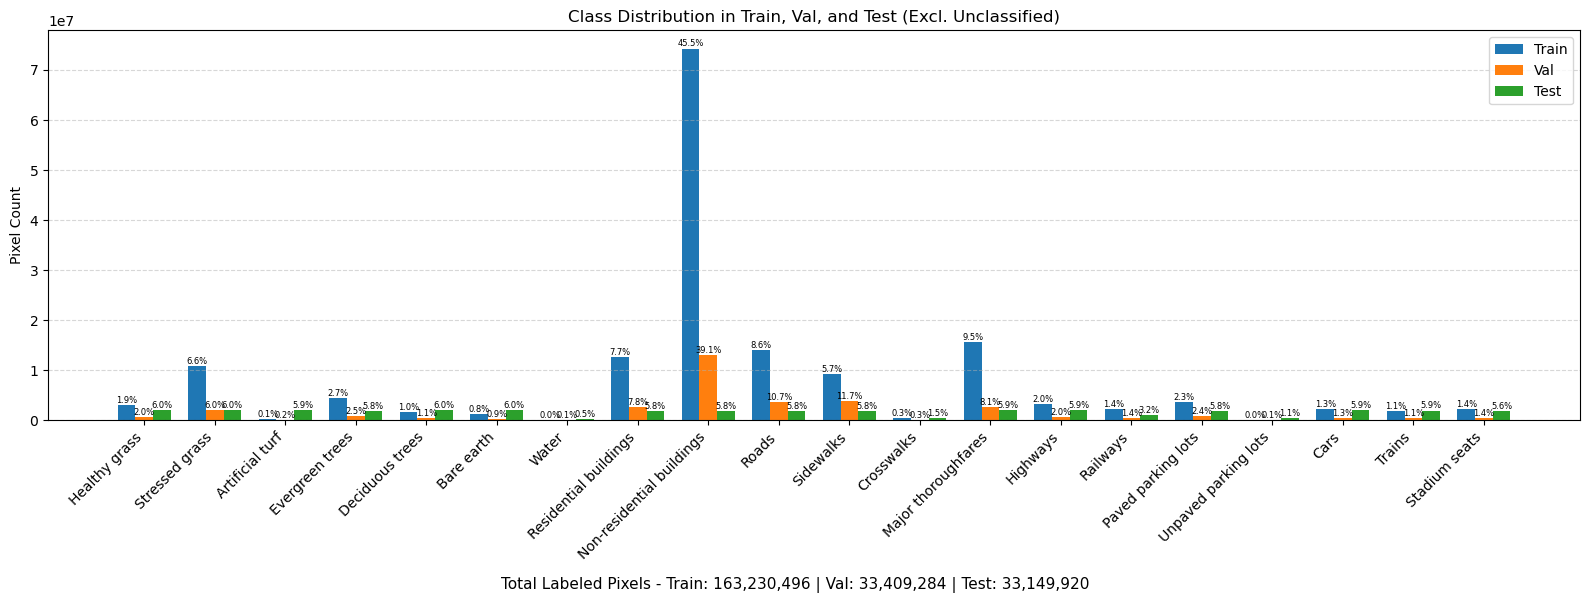

In [23]:
x = range(len(class_ids))
width = 0.25

plt.figure(figsize=(16, 6))
bars_train = plt.bar([i - width for i in x], train_excl0, width=width, label='Train')
bars_val   = plt.bar([i for i in x], val_excl0, width=width, label='Val')
bars_test  = plt.bar([i + width for i in x], test_excl0, width=width, label='Test')

plt.xticks(x, class_names, rotation=45, ha='right')
plt.ylabel('Pixel Count')
plt.title('Class Distribution in Train, Val, and Test (Excl. Unclassified)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Annotate total on top
for i in x:
    if train_excl0[i] > 0:
        plt.text(i - width, train_excl0[i] * 1.002, f'{train_pct[i]:.1f}%', ha='center', va='bottom', fontsize=6)
    if val_excl0[i] > 0:
        plt.text(i, val_excl0[i] * 1.002, f'{val_pct[i]:.1f}%', ha='center', va='bottom', fontsize=6)
    if test_excl0[i] > 0:
        plt.text(i + width, test_excl0[i] * 1.002, f'{test_pct[i]:.1f}%', ha='center', va='bottom', fontsize=6)


# Totals
plt.figtext(0.5, 0.01,
    f'Total Labeled Pixels - Train: {total_train:,} | Val: {total_val:,} | Test: {total_test:,}',
    ha='center', fontsize=11)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

**Prepare Majority Classification - We need at least 50% labeled pixels**

In [7]:
train_label_dir = 'data/patches/train'
val_label_dir = 'data/patches/val'
test_label_dir = 'data/patches/test'

In [8]:
def count_majority_labeled_patches(label_dir, ignore_label=0, threshold=0.5):
    label_files = [f for f in os.listdir(label_dir) if f.endswith('_label.npy')]
    count = 0

    for fname in label_files:
        label_path = os.path.join(label_dir, fname)
        label = np.load(label_path)

        # Total pixels in patch
        total_pixels = label.size

        # Count labeled pixels (not ignore label)
        labeled_pixels = np.sum(label != ignore_label)

        # Check if labeled pixels are >= 50%
        if labeled_pixels / total_pixels >= threshold:
            count += 1

    return count, len(label_files)

In [9]:
train_count, train_total = count_majority_labeled_patches(train_label_dir)
val_count, val_total = count_majority_labeled_patches(val_label_dir)
test_count, test_total = count_majority_labeled_patches(test_label_dir)

print(f"Train: {train_count}/{train_total} patches have ≥50% labeled pixels")
print(f"Val:   {val_count}/{val_total} patches have ≥50% labeled pixels")
print(f"Test:  {test_count}/{test_total} patches have ≥50% labeled pixels")

Train: 2400/4063 patches have ≥50% labeled pixels
Val:   143/2888 patches have ≥50% labeled pixels
Test:  50/17409 patches have ≥50% labeled pixels


In [ ]:
def get_patches_with_labeled_ratio(label_dir, threshold=0.5, ignore_label=0):
    files = [f for f in os.listdir(label_dir) if f.endswith('_label.npy')]
    qualified = []

    for f in files:
        label = np.load(os.path.join(label_dir, f))
        total = label.size
        labeled = np.sum(label != ignore_label)
        if total == 0:
            continue
        if labeled / total > threshold:
            base = f.replace('_label.npy', '')
            qualified.append(base)
    return qualified

def copy_patch(base_name, src_dir, dst_dir):
    os.makedirs(dst_dir, exist_ok=True)
    for suffix in ['_label.npy', '_img.npy']:
        src = os.path.join(src_dir, base_name + suffix)
        dst = os.path.join(dst_dir, base_name + suffix)
        if os.path.exists(src):
            shutil.copy(src, dst)

def classification_split_v2(base_dir, threshold=0.5, ignore_label=0):
    src_train = os.path.join(base_dir, 'train')
    src_val   = os.path.join(base_dir, 'val')
    src_test  = os.path.join(base_dir, 'test')

    dst_train = os.path.join(base_dir, 'train_classification')
    dst_val   = os.path.join(base_dir, 'val_classification')
    dst_test  = os.path.join(base_dir, 'test_classification')

    for d in [dst_train, dst_val, dst_test]:
        os.makedirs(d, exist_ok=True)

    # 1. Test classification: val + test patches with >50% labeled pixels
    val_patches = get_patches_with_labeled_ratio(src_val, threshold, ignore_label)
    test_patches = get_patches_with_labeled_ratio(src_test, threshold, ignore_label)
    test_class_patches = val_patches + test_patches

    print(f"Found {len(val_patches)} val and {len(test_patches)} test patches with >{threshold*100:.0f}% labeled pixels")

    #for base in test_class_patches:
    #    if base + '_label.npy' in os.listdir(src_val):
    #        copy_patch(base, src_val, dst_test)
    #    else:
    #        copy_patch(base, src_test, dst_test)

    # 2. Get train patches with >50% labeled pixels
    train_candidates = get_patches_with_labeled_ratio(src_train, threshold, ignore_label)
    print(f"Found {len(train_candidates)} train patches with >{threshold*100:.0f}% labeled pixels")

    # 3. Randomly sample same number as test_class_patches for val_classification
    val_count = len(test_class_patches)
    random.shuffle(train_candidates)
    val_sample = train_candidates[:val_count]
    train_remaining = train_candidates[val_count:]

    #for base in val_sample:
        #copy_patch(base, src_train, dst_val)

    #for base in train_remaining:
        #copy_patch(base, src_train, dst_train)

    print(f"\n✅ Copied {len(test_class_patches)} to test_classification")
    print(f"✅ Copied {len(val_sample)} to val_classification")
    print(f"✅ Copied {len(train_remaining)} to train_classification")


In [15]:
classification_split_v2('data/patches', threshold=0.5)

Found 143 val and 50 test patches with >50% labeled pixels
Found 2400 train patches with >50% labeled pixels

✅ Copied 193 to test_classification
✅ Copied 193 to val_classification
✅ Copied 2207 to train_classification
